In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [53]:
df = pd.read_csv(r'E:\End to End Project\Project 1\Notebook\data\stud.csv')

In [5]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [6]:
df.tail()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77
999,female,group D,some college,free/reduced,none,77,86,86


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race_ethnicity               1000 non-null   str  
 2   parental_level_of_education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test_preparation_course      1000 non-null   str  
 5   math_score                   1000 non-null   int64
 6   reading_score                1000 non-null   int64
 7   writing_score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


In [8]:
df.isnull().sum()

gender                         0
race_ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
dtype: int64

In [10]:
df[df.duplicated()]

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score


In [11]:
df.shape

(1000, 8)

In [18]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
gender,1000,2,female,518,NaN,NaN,NaN,NaN,NaN,NaN,NaN
race_ethnicity,1000,5,group C,319,NaN,NaN,NaN,NaN,NaN,NaN,NaN
parental_level_of_education,1000,6,some college,226,NaN,NaN,NaN,NaN,NaN,NaN,NaN
lunch,1000,2,standard,645,NaN,NaN,NaN,NaN,NaN,NaN,NaN
test_preparation_course,1000,2,none,642,NaN,NaN,NaN,NaN,NaN,NaN,NaN
math_score,1000.0,NaN,NaN,NaN,66.089,15.16308,0.0,57.0,66.0,77.0,100.0
reading_score,1000.0,NaN,NaN,NaN,69.169,14.600192,17.0,59.0,70.0,79.0,100.0
writing_score,1000.0,NaN,NaN,NaN,68.054,15.195657,10.0,57.75,69.0,79.0,100.0


In [54]:
catigorical_columns = df.select_dtypes(include=['object']).columns.to_list()
numerical_columns = df.select_dtypes(exclude=['object']).columns.to_list()

C:\Users\asus\AppData\Local\Temp\ipykernel_19696\2204989992.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  catigorical_columns = df.select_dtypes(include=['object']).columns.to_list()


In [55]:
for i in catigorical_columns:
    print(f"Column Name: {i}")
    print(df[i].value_counts())
    print('-'*25)

Column Name: gender
gender
female    518
male      482
Name: count, dtype: int64
-------------------------
Column Name: race_ethnicity
race_ethnicity
group C    319
group D    262
group B    190
group E    140
group A     89
Name: count, dtype: int64
-------------------------
Column Name: parental_level_of_education
parental_level_of_education
some college          226
associate's degree    222
high school           196
some high school      179
bachelor's degree     118
master's degree        59
Name: count, dtype: int64
-------------------------
Column Name: lunch
lunch
standard        645
free/reduced    355
Name: count, dtype: int64
-------------------------
Column Name: test_preparation_course
test_preparation_course
none         642
completed    358
Name: count, dtype: int64
-------------------------


In [56]:
df['total score'] = df['math_score']+df['reading_score']+df['writing_score']
df['avg score'] = (df['math_score']+df['reading_score']+df['writing_score'])/3

In [57]:
math_full = df[df['math_score'] == 100]['math_score'].count()
reading_full = df[df['reading_score'] == 100]['reading_score'].count()
writing_full = df[df['writing_score'] == 100]['writing_score'].count()
print(f'Number of students with full marks in Maths: {math_full}')
print(f'Number of students with full marks in Writing: {writing_full}')
print(f'Number of students with full marks in Reading: {reading_full}')

Number of students with full marks in Maths: 7
Number of students with full marks in Writing: 14
Number of students with full marks in Reading: 17


In [51]:
reading_less_20 = df[df['reading_score'] <= 20]['reading_score'].count()
writing_less_20 = df[df['writing_score'] <= 20]['writing_score'].count()
math_less_20 = df[df['math_score'] <= 20]['math_score'].count()

print(f'Number of students with less than 20 marks in Maths: {math_less_20}')
print(f'Number of students with less than 20 marks in Writing: {writing_less_20}')
print(f'Number of students with less than 20 marks in Reading: {reading_less_20}')

Number of students with less than 20 marks in Maths: 4
Number of students with less than 20 marks in Writing: 3
Number of students with less than 20 marks in Reading: 1


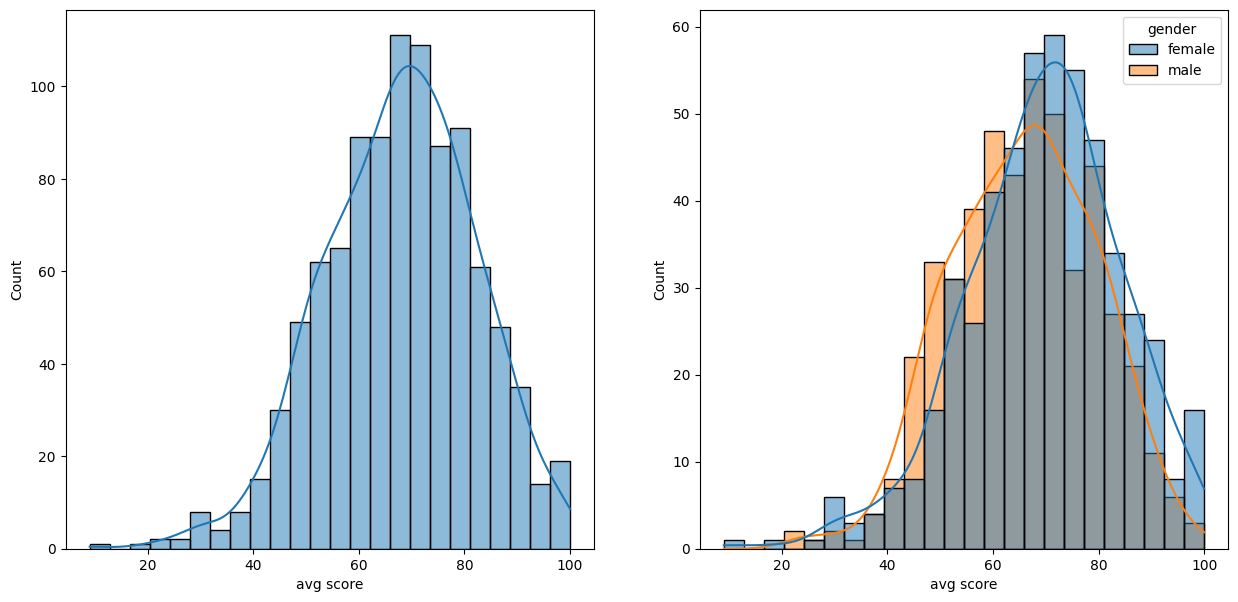

In [60]:
plt.figure(figsize=(15, 7))
plt.subplot(1,2,1)
sns.histplot(x= 'avg score', data = df, kde = True)
plt.subplot(1,2,2)
sns.histplot(x= 'avg score', data = df, hue = 'gender', kde = True)
plt.show()

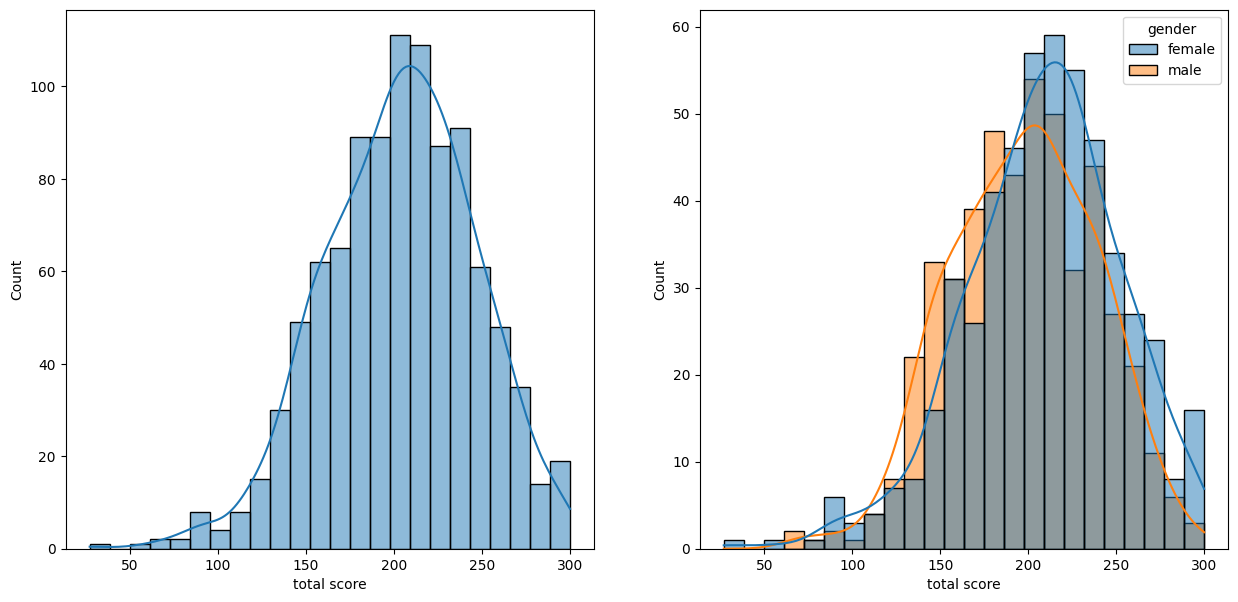

In [62]:
plt.figure(figsize=(15,7))
plt.subplot(1,2,1)
sns.histplot(x= 'total score', data = df, kde = True)
plt.subplot(1,2,2)
sns.histplot(x= 'total score', data = df, kde = True, hue = 'gender')
plt.show()     

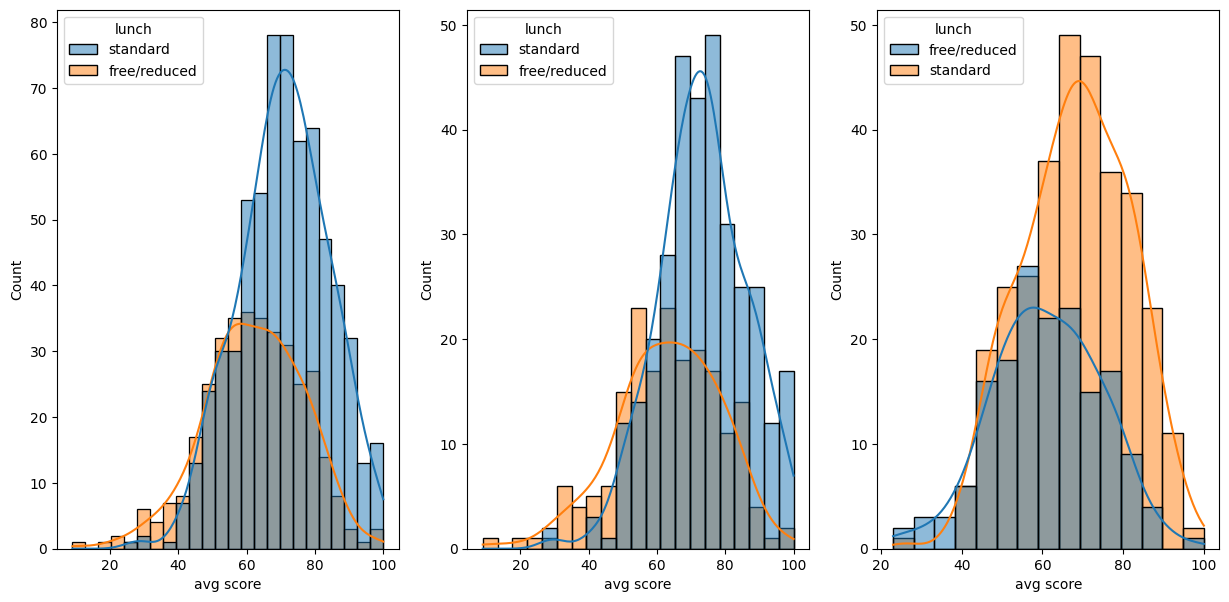

In [65]:
plt.figure(figsize=(15,7))
plt.subplot(1,3,1)
sns.histplot(data=df,x='avg score',kde=True,hue='lunch')
plt.subplot(1,3,2)
sns.histplot(data=df[df.gender=='female'],x='avg score',kde=True,hue='lunch')
plt.subplot(1,3,3)
sns.histplot(data=df[df.gender=='male'],x='avg score',kde=True,hue='lunch')
plt.show()

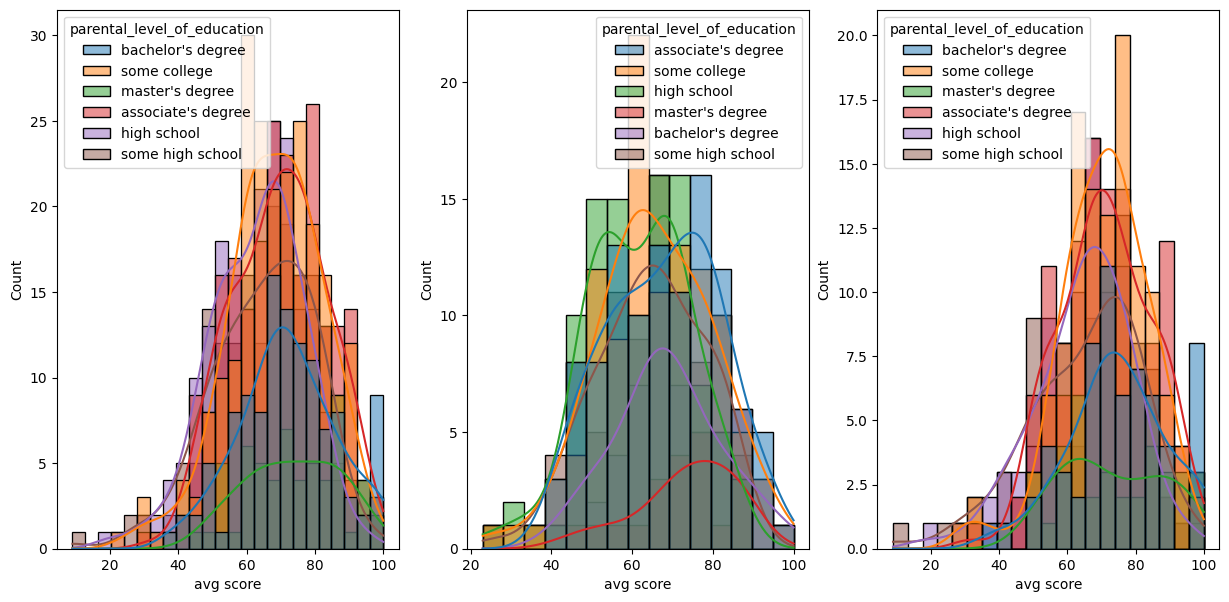

In [66]:
plt.figure(figsize=(15,7))
plt.subplot(1,3,1)
sns.histplot(data = df, x = 'avg score', kde = True, hue = 'parental_level_of_education')
plt.subplot(1,3,2)
sns.histplot(data = df[df.gender == 'male'], x = 'avg score', kde = True, hue='parental_level_of_education')
plt.subplot(1,3,3)
sns.histplot(data = df[df.gender == 'female'], x = 'avg score', kde = True, hue='parental_level_of_education')
plt.show()

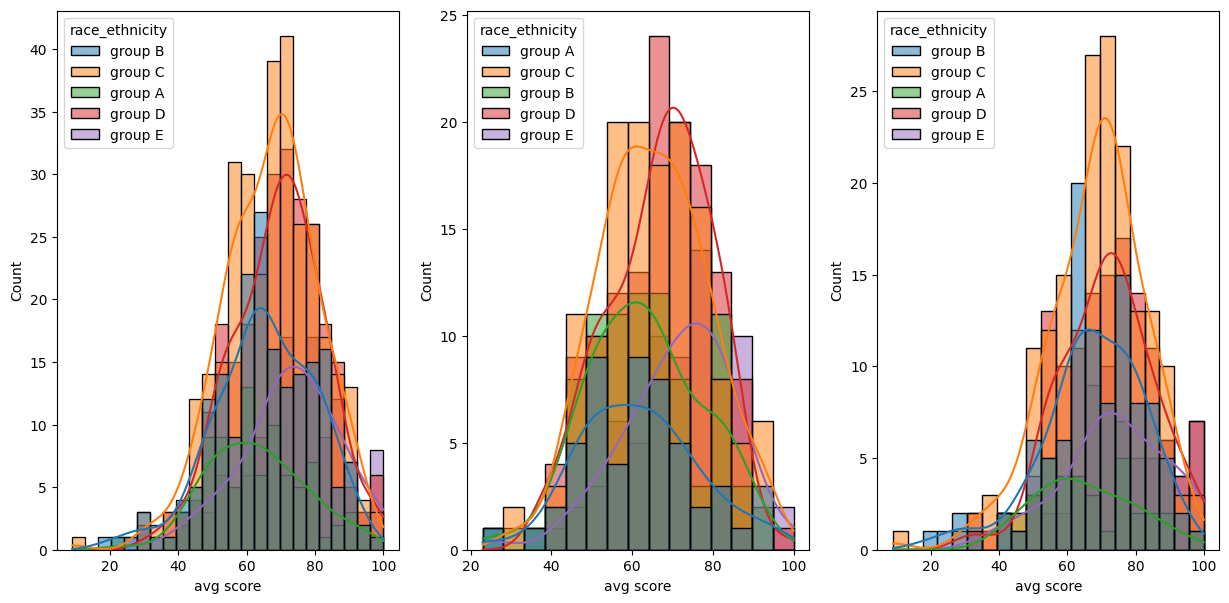

In [67]:
plt.figure(figsize=(15,7))
plt.subplot(1,3,1)
sns.histplot(data = df, x = 'avg score', kde = True, hue = 'race_ethnicity')
plt.subplot(1,3,2)
sns.histplot(data = df[df.gender == 'male'], x = 'avg score', kde = True, hue='race_ethnicity')
plt.subplot(1,3,3)
sns.histplot(data = df[df.gender == 'female'], x = 'avg score', kde = True, hue='race_ethnicity')
plt.show()

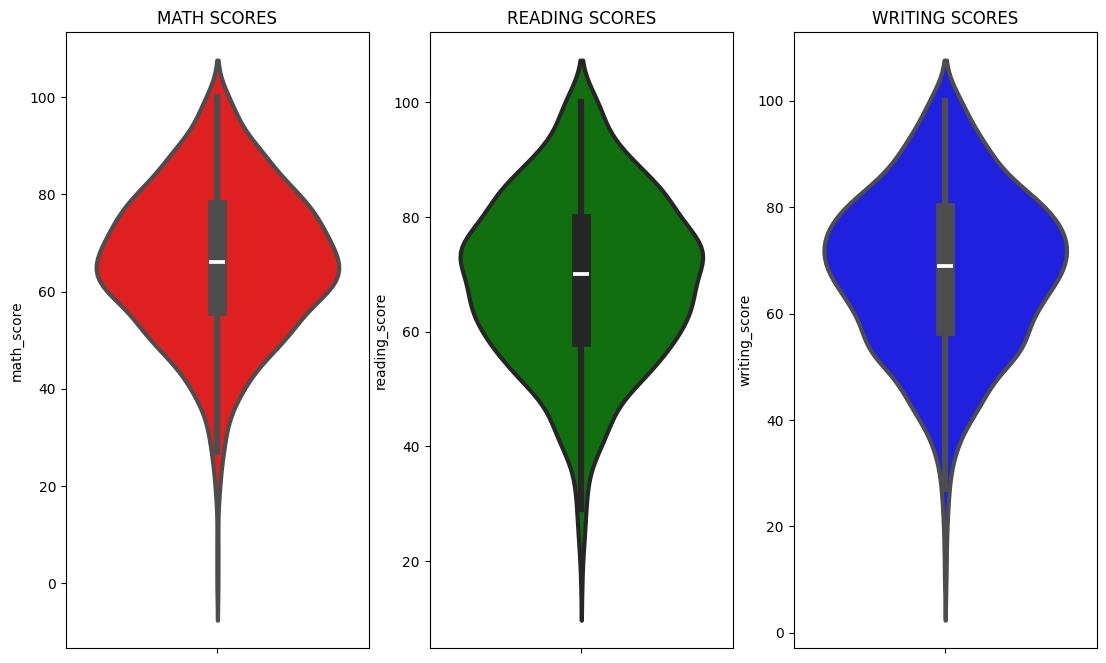

In [68]:

plt.figure(figsize=(18,8))
plt.subplot(1, 4, 1)
plt.title('MATH SCORES')
sns.violinplot(y='math_score',data=df,color='red',linewidth=3)
plt.subplot(1, 4, 2)
plt.title('READING SCORES')
sns.violinplot(y='reading_score',data=df,color='green',linewidth=3)
plt.subplot(1, 4, 3)
plt.title('WRITING SCORES')
sns.violinplot(y='writing_score',data=df,color='blue',linewidth=3)
plt.show()

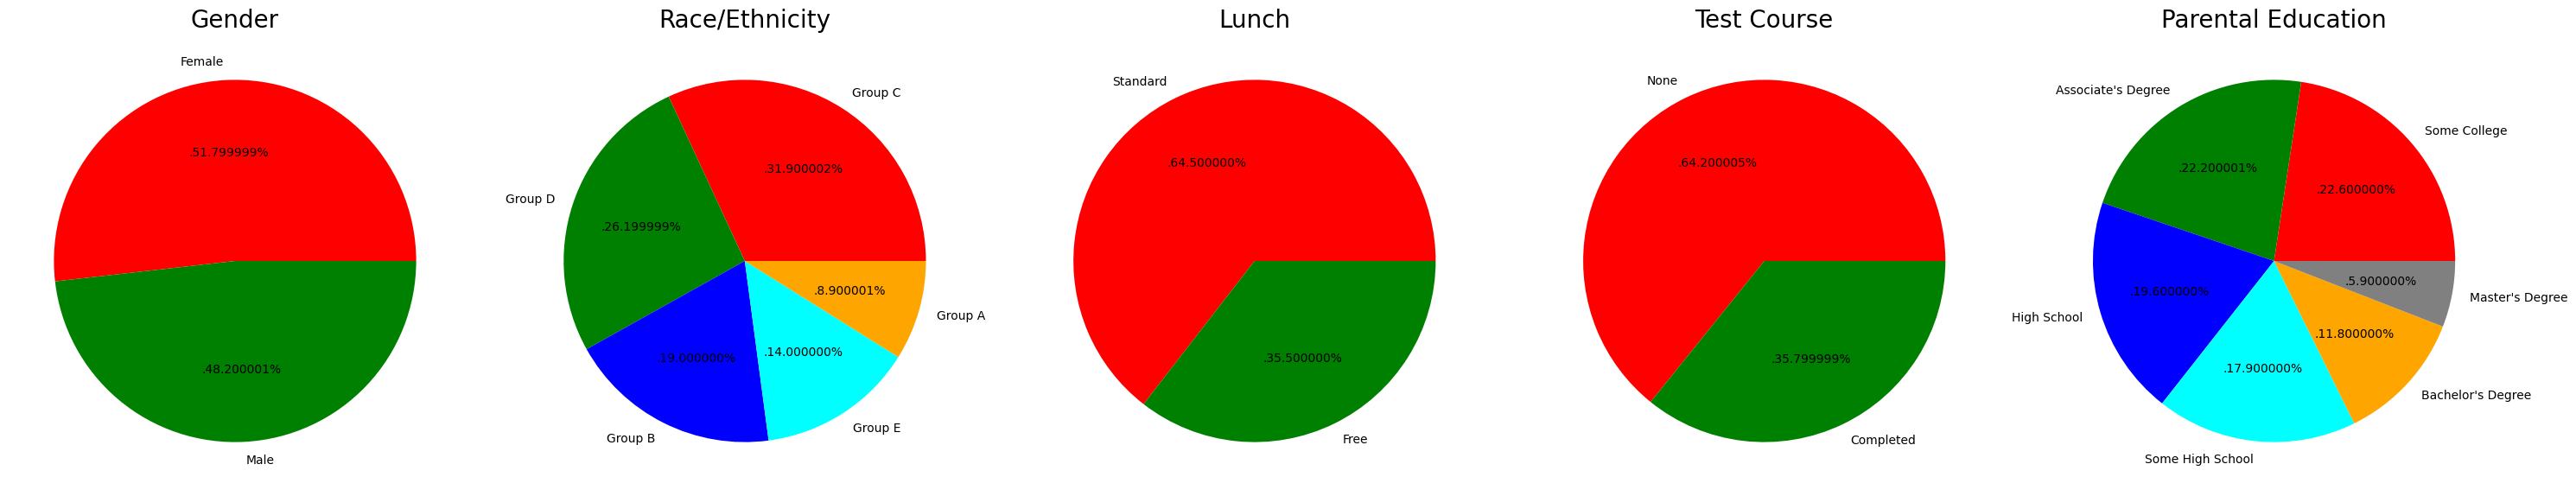

In [69]:
plt.rcParams['figure.figsize'] = (30, 12)

plt.subplot(1, 5, 1)
size = df['gender'].value_counts()
labels = 'Female', 'Male'
color = ['red','green']


plt.pie(size, colors = color, labels = labels,autopct = '.%2f%%')
plt.title('Gender', fontsize = 20)
plt.axis('off')



plt.subplot(1, 5, 2)
size = df['race_ethnicity'].value_counts()
labels = 'Group C', 'Group D','Group B','Group E','Group A'
color = ['red', 'green', 'blue', 'cyan','orange']

plt.pie(size, colors = color,labels = labels,autopct = '.%2f%%')
plt.title('Race/Ethnicity', fontsize = 20)
plt.axis('off')



plt.subplot(1, 5, 3)
size = df['lunch'].value_counts()
labels = 'Standard', 'Free'
color = ['red','green']

plt.pie(size, colors = color,labels = labels,autopct = '.%2f%%')
plt.title('Lunch', fontsize = 20)
plt.axis('off')


plt.subplot(1, 5, 4)
size = df['test_preparation_course'].value_counts()
labels = 'None', 'Completed'
color = ['red','green']

plt.pie(size, colors = color,labels = labels,autopct = '.%2f%%')
plt.title('Test Course', fontsize = 20)
plt.axis('off')


plt.subplot(1, 5, 5)
size = df['parental_level_of_education'].value_counts()
labels = 'Some College', "Associate's Degree",'High School','Some High School',"Bachelor's Degree","Master's Degree"
color = ['red', 'green', 'blue', 'cyan','orange','grey']

plt.pie(size, colors = color,labels = labels,autopct = '.%2f%%')
plt.title('Parental Education', fontsize = 20)
plt.axis('off')


plt.tight_layout()
plt.grid()

plt.show()

C:\Users\asus\AppData\Local\Temp\ipykernel_19696\2601008339.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='gender', data=df, palette='Set1')


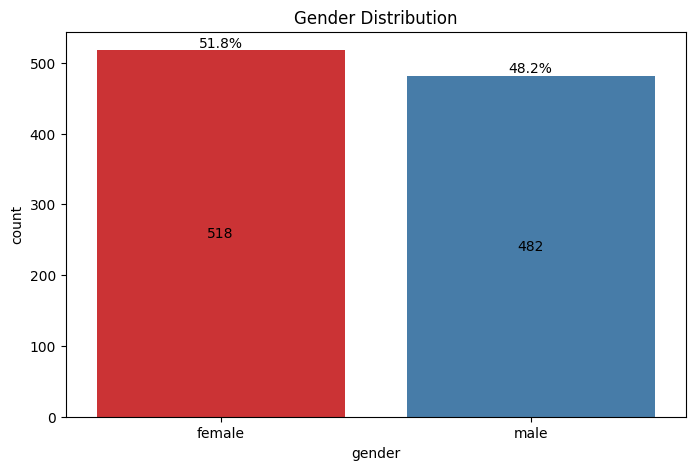

In [72]:
plt.figure(figsize=(8,5))

ax = sns.countplot(x='gender', data=df, palette='Set1')

total = len(df)

for p in ax.patches:
    count = int(p.get_height())
    percentage = 100 * count / total

    # Count inside the bar
    ax.annotate(
        f'{count}',
        (p.get_x() + p.get_width()/2, count/2),
        ha='center',
        va='center'
    )

    # Percentage on top of the bar
    ax.annotate(
        f'{percentage:.1f}%',
        (p.get_x() + p.get_width()/2, count),
        ha='center',
        va='bottom'
    )

plt.title('Gender Distribution')
plt.show()

C:\Users\asus\AppData\Local\Temp\ipykernel_19696\2095466117.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='race_ethnicity', data=df, palette='Set1')


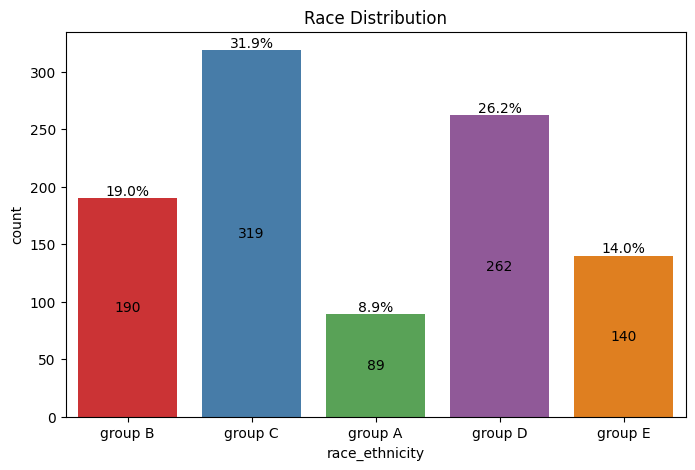

In [73]:
plt.figure(figsize=(8,5))

ax = sns.countplot(x='race_ethnicity', data=df, palette='Set1')

total = len(df)

for p in ax.patches:
    count = int(p.get_height())
    percentage = 100 * count / total

    # Count inside the bar
    ax.annotate(
        f'{count}',
        (p.get_x() + p.get_width()/2, count/2),
        ha='center',
        va='center'
    )

    # Percentage on top of the bar
    ax.annotate(
        f'{percentage:.1f}%',
        (p.get_x() + p.get_width()/2, count),
        ha='center',
        va='bottom'
    )

plt.title('Race Distribution')
plt.show()

C:\Users\asus\AppData\Local\Temp\ipykernel_19696\3389910776.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='parental_level_of_education', data=df, palette='Set1')


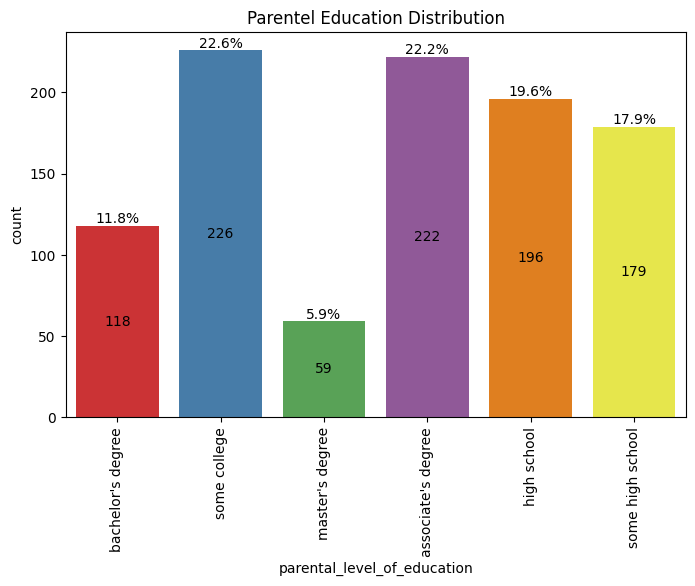

In [75]:
plt.figure(figsize=(8,5))

ax = sns.countplot(x='parental_level_of_education', data=df, palette='Set1')

total = len(df)

for p in ax.patches:
    count = int(p.get_height())
    percentage = 100 * count / total

    # Count inside the bar
    ax.annotate(
        f'{count}',
        (p.get_x() + p.get_width()/2, count/2),
        ha='center',
        va='center'
    )

    # Percentage on top of the bar
    ax.annotate(
        f'{percentage:.1f}%',
        (p.get_x() + p.get_width()/2, count),
        ha='center',
        va='bottom'
    )

plt.title('Parentel Education Distribution')
plt.xticks(rotation = 90)
plt.show()

C:\Users\asus\AppData\Local\Temp\ipykernel_19696\44929271.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='lunch', data=df, palette='Set1')


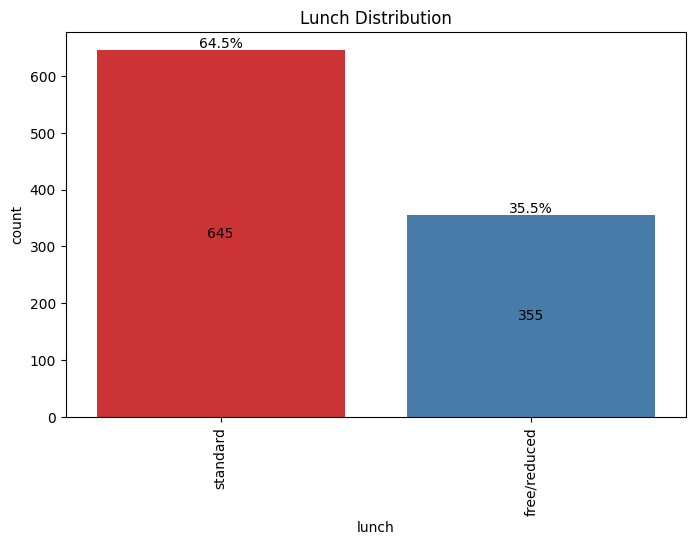

In [76]:
plt.figure(figsize=(8,5))

ax = sns.countplot(x='lunch', data=df, palette='Set1')

total = len(df)

for p in ax.patches:
    count = int(p.get_height())
    percentage = 100 * count / total

    # Count inside the bar
    ax.annotate(
        f'{count}',
        (p.get_x() + p.get_width()/2, count/2),
        ha='center',
        va='center'
    )

    # Percentage on top of the bar
    ax.annotate(
        f'{percentage:.1f}%',
        (p.get_x() + p.get_width()/2, count),
        ha='center',
        va='bottom'
    )

plt.title('Lunch Distribution')
plt.xticks(rotation = 90)
plt.show()

C:\Users\asus\AppData\Local\Temp\ipykernel_19696\3227930163.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='test_preparation_course', data=df, palette='Set1')


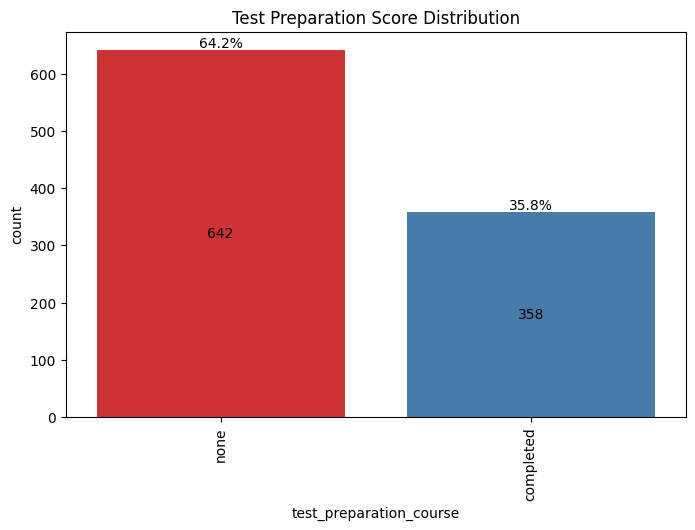

In [77]:
plt.figure(figsize=(8,5))

ax = sns.countplot(x='test_preparation_course', data=df, palette='Set1')

total = len(df)

for p in ax.patches:
    count = int(p.get_height())
    percentage = 100 * count / total

    # Count inside the bar
    ax.annotate(
        f'{count}',
        (p.get_x() + p.get_width()/2, count/2),
        ha='center',
        va='center'
    )

    # Percentage on top of the bar
    ax.annotate(
        f'{percentage:.1f}%',
        (p.get_x() + p.get_width()/2, count),
        ha='center',
        va='bottom'
    )

plt.title('Test Preparation Score Distribution')
plt.xticks(rotation = 90)
plt.show()

C:\Users\asus\AppData\Local\Temp\ipykernel_19696\1720327845.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['gender'],data=df,palette ='bright',ax=ax[0],saturation=0.95)


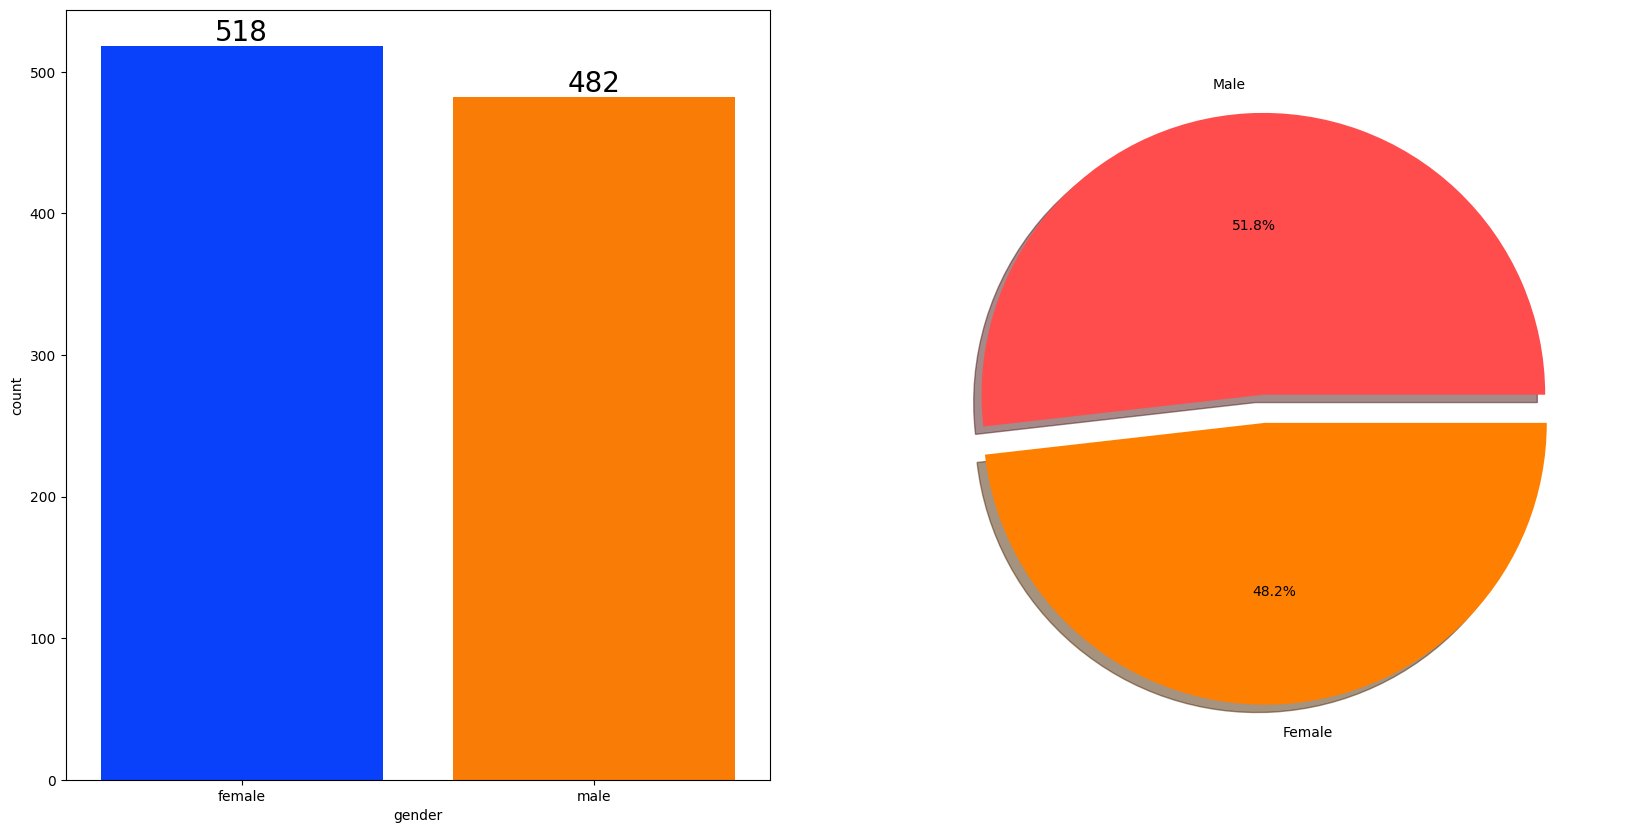

In [78]:
f,ax=plt.subplots(1,2,figsize=(20,10))
sns.countplot(x=df['gender'],data=df,palette ='bright',ax=ax[0],saturation=0.95)
for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=20)
    
plt.pie(x=df['gender'].value_counts(),labels=['Male','Female'],explode=[0,0.1],autopct='%1.1f%%',shadow=True,colors=['#ff4d4d','#ff8000'])
plt.show()

In [84]:
import warnings
warnings.filterwarnings('ignore')

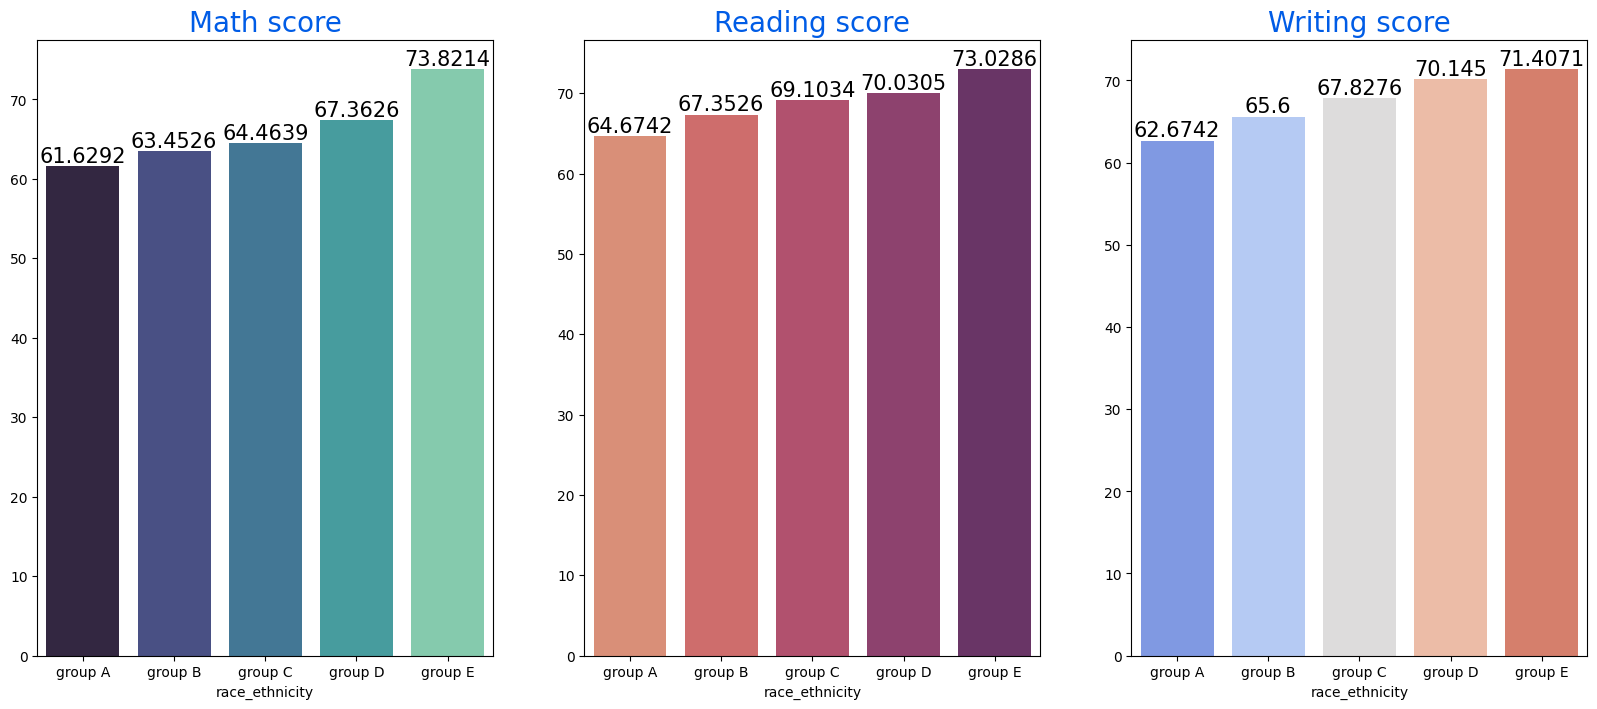

In [85]:
Group_data2=df.groupby('race_ethnicity')
f,ax=plt.subplots(1,3,figsize=(20,8))
sns.barplot(x=Group_data2['math_score'].mean().index,y=Group_data2['math_score'].mean().values,palette = 'mako',ax=ax[0])
ax[0].set_title('Math score',color='#005ce6',size=20)

for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=15)

sns.barplot(x=Group_data2['reading_score'].mean().index,y=Group_data2['reading_score'].mean().values,palette = 'flare',ax=ax[1])
ax[1].set_title('Reading score',color='#005ce6',size=20)

for container in ax[1].containers:
    ax[1].bar_label(container,color='black',size=15)

sns.barplot(x=Group_data2['writing_score'].mean().index,y=Group_data2['writing_score'].mean().values,palette = 'coolwarm',ax=ax[2])
ax[2].set_title('Writing score',color='#005ce6',size=20)

for container in ax[2].containers:
    ax[2].bar_label(container,color='black',size=15)

plt.show()

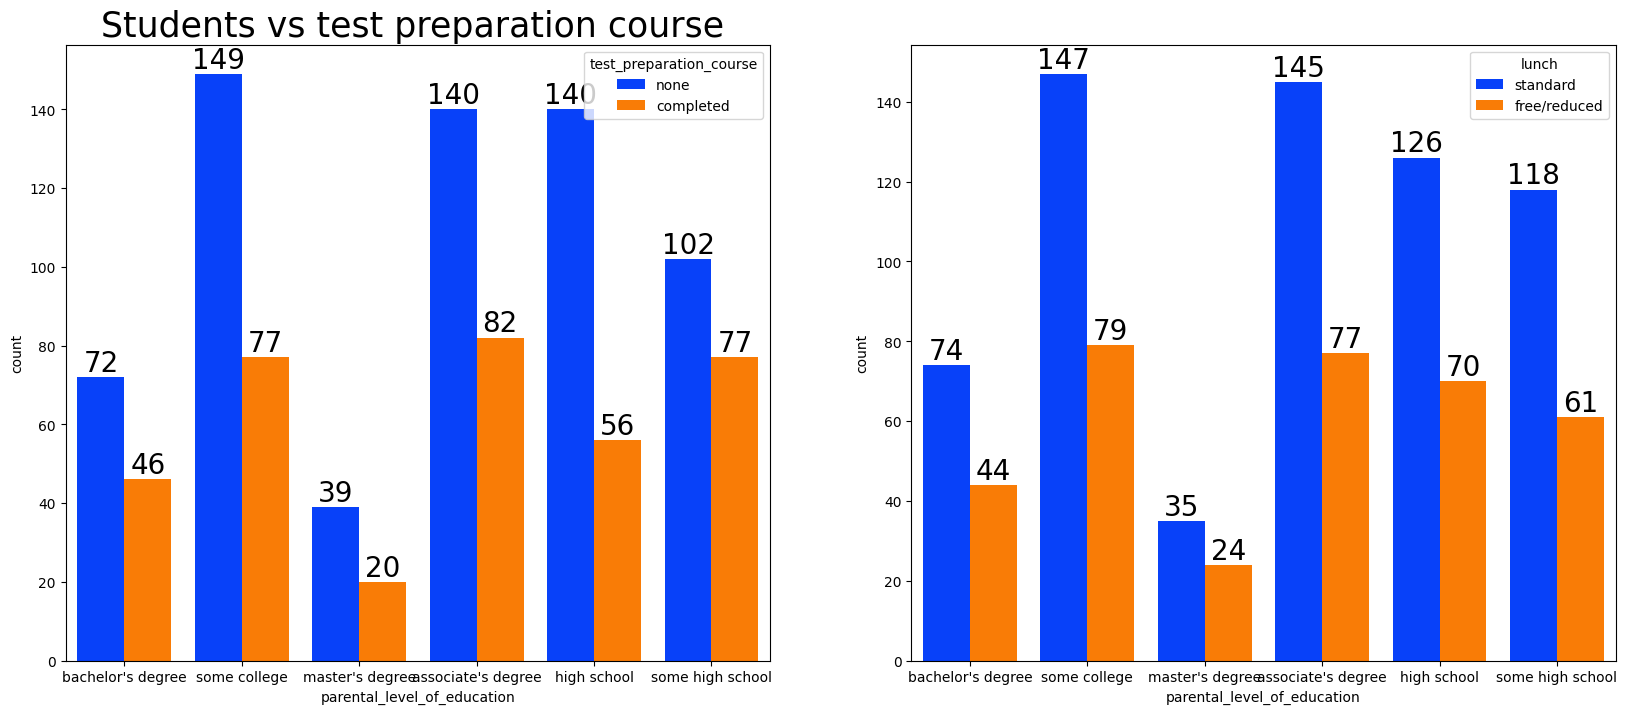

In [87]:
f,ax=plt.subplots(1,2,figsize=(20,8))
sns.countplot(x=df['parental_level_of_education'],data=df,palette = 'bright',hue='test_preparation_course',saturation=0.95,ax=ax[0])
ax[0].set_title('Students vs test preparation course ',color='black',size=25)
for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=20)
    
sns.countplot(x=df['parental_level_of_education'],data=df,palette = 'bright',hue='lunch',saturation=0.95,ax=ax[1])
for container in ax[1].containers:
    ax[1].bar_label(container,color='black',size=20)   

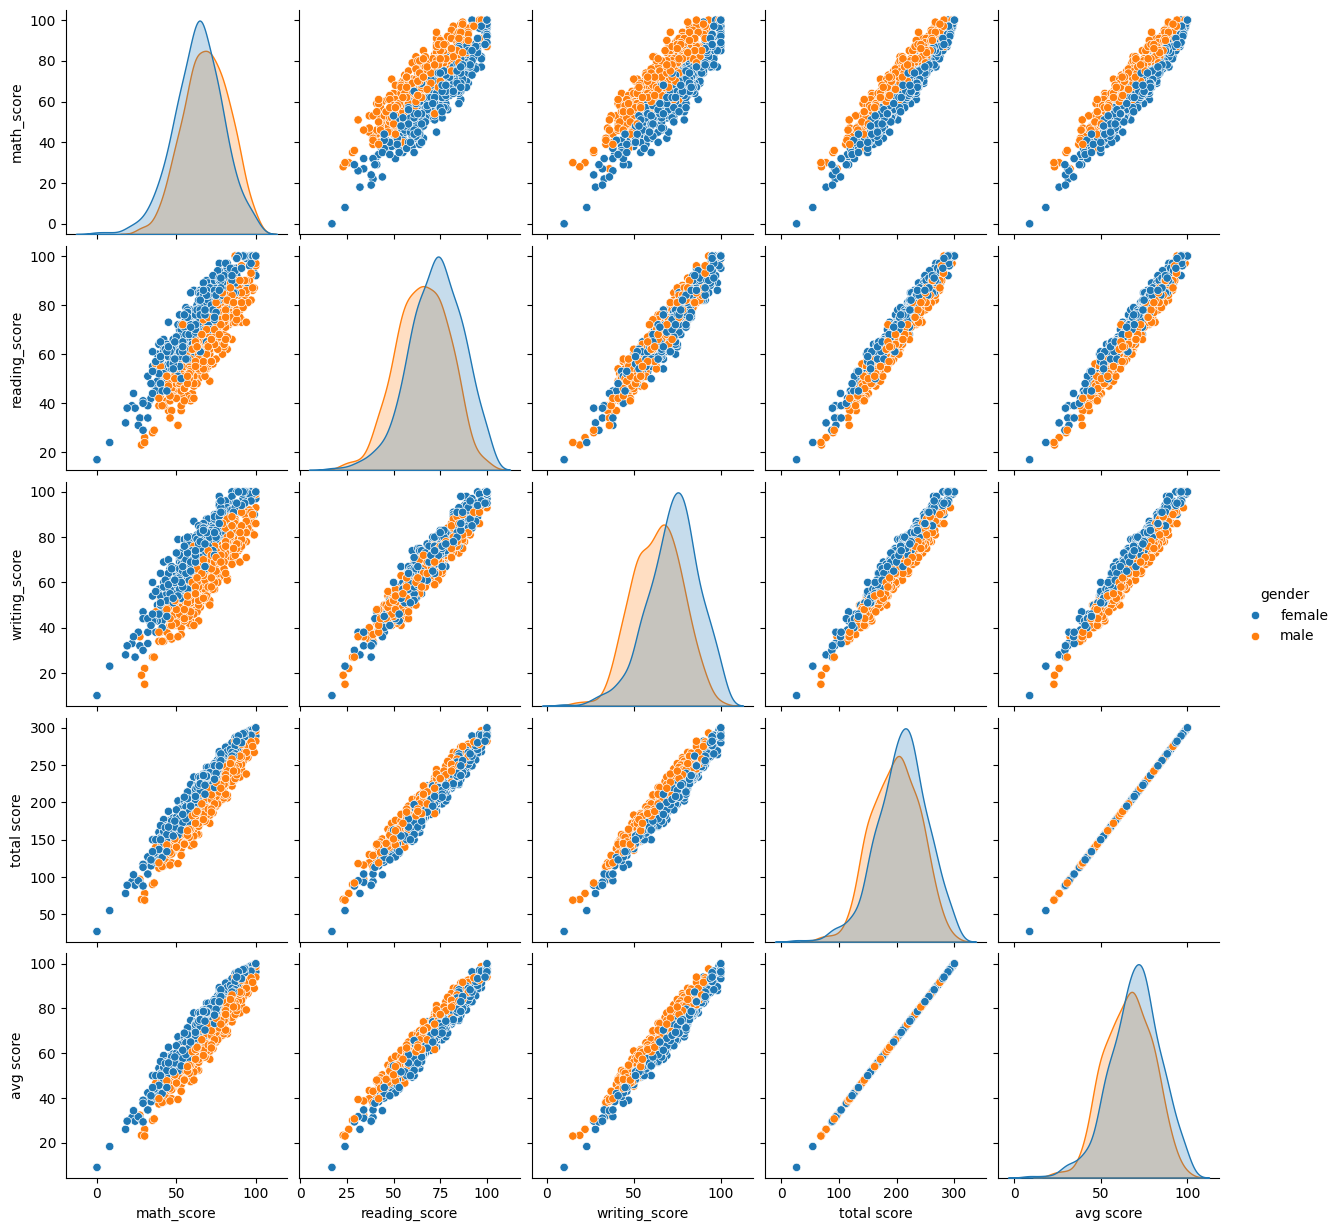

In [88]:
sns.pairplot(df,hue = 'gender')
plt.show()

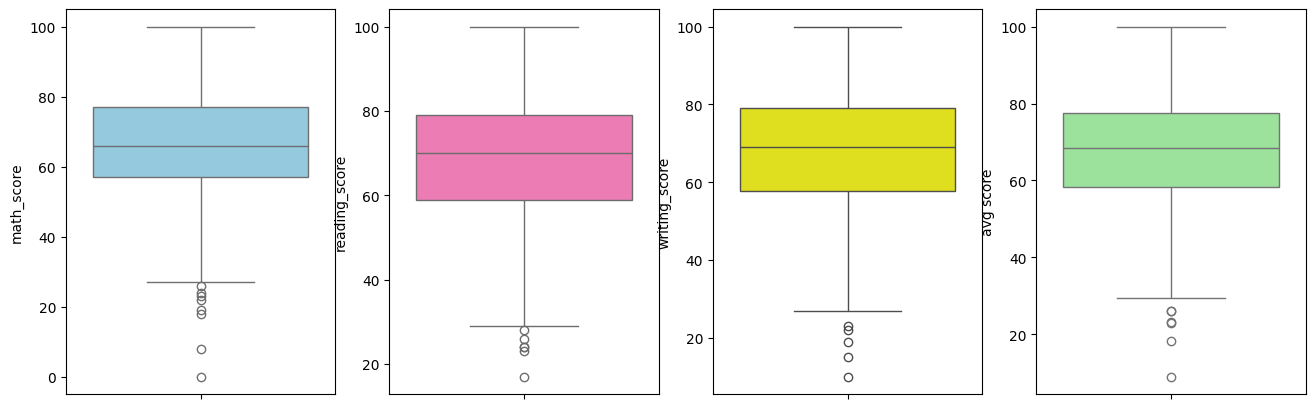

In [89]:
plt.subplots(1,4,figsize=(16,5))
plt.subplot(141)
sns.boxplot(df['math_score'],color='skyblue')
plt.subplot(142)
sns.boxplot(df['reading_score'],color='hotpink')
plt.subplot(143)
sns.boxplot(df['writing_score'],color='yellow')
plt.subplot(144)
sns.boxplot(df['avg score'],color='lightgreen')
plt.show()

<Axes: xlabel='lunch', ylabel='writing_score'>

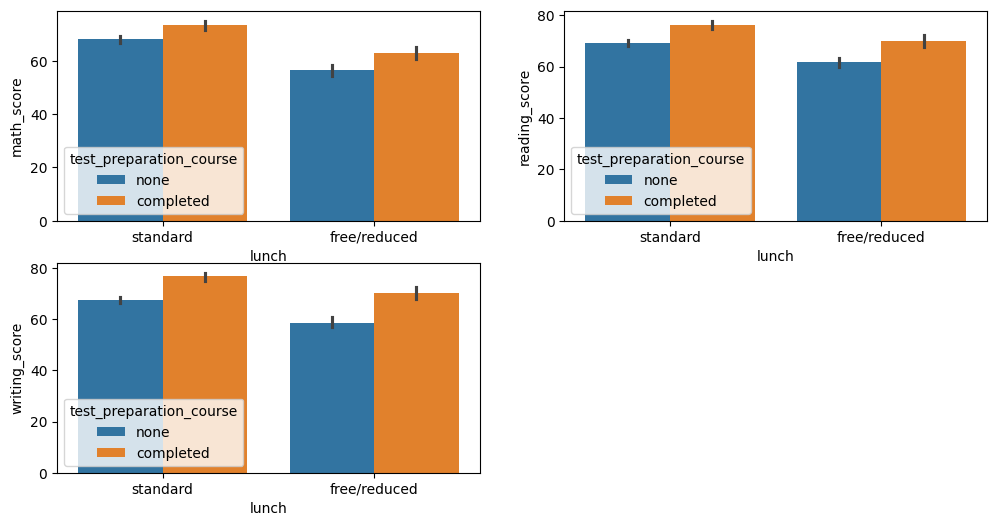

In [90]:
plt.figure(figsize=(12,6))
plt.subplot(2,2,1)
sns.barplot (x=df['lunch'], y=df['math_score'], hue=df['test_preparation_course'])
plt.subplot(2,2,2)
sns.barplot (x=df['lunch'], y=df['reading_score'], hue=df['test_preparation_course'])
plt.subplot(2,2,3)
sns.barplot (x=df['lunch'], y=df['writing_score'], hue=df['test_preparation_course'])

In [ ]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total score,avg score
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333
